<a href="https://colab.research.google.com/github/vanshikavarshney80-bit/CodeVedX/blob/main/Student_performance_prediction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [2]:

np.random.seed(42)

records = 200

attendance = np.random.randint(60, 101, records)
study_hours = np.random.randint(1, 9, records)
internal_marks = np.random.randint(40, 96, records)
assignments = np.random.randint(5, 11, records)


final_marks = (
    attendance * 0.25 +
    study_hours * 5 +
    internal_marks * 0.5 +
    assignments * 2 +
    np.random.randint(-5, 6, records)
)

final_marks = np.clip(final_marks, 35, 100).astype(int)

data = pd.DataFrame({
    "Attendance": attendance,
    "Study_Hours": study_hours,
    "Internal_Marks": internal_marks,
    "Assignments": assignments,
    "Final_Marks": final_marks
})

print("First 10 Records")
print(data.head(10))

print("\nTotal Records:", len(data))

First 10 Records
   Attendance  Study_Hours  Internal_Marks  Assignments  Final_Marks
0          98            3              66            6           80
1          88            7              81            9          100
2          74            8              41            6           90
3          67            8              65            9          100
4          80            1              56            7           63
5          98            1              79            9           91
6          78            4              72            8           93
7          82            3              48            5           65
8          70            6              82            9          100
9          70            8              93            9          100

Total Records: 200


In [3]:
print("Dataset Information\n")

print(data.info())

print("\nStatistical Summary\n")

print(data.describe())

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Attendance      200 non-null    int64
 1   Study_Hours     200 non-null    int64
 2   Internal_Marks  200 non-null    int64
 3   Assignments     200 non-null    int64
 4   Final_Marks     200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB
None

Statistical Summary

       Attendance  Study_Hours  Internal_Marks  Assignments  Final_Marks
count  200.000000   200.000000      200.000000   200.000000   200.000000
mean    80.050000     4.640000       68.220000     7.525000    88.065000
std     12.279717     2.435169       16.232965     1.683313    12.826667
min     60.000000     1.000000       40.000000     5.000000    56.000000
25%     68.000000     3.000000       55.000000     6.000000    78.750000
50%     82.000000     4.000000       68.000000     8.000000    92.00000

In [4]:


data.loc[5, "Attendance"] = np.nan
data.loc[15, "Study_Hours"] = np.nan
data.loc[25, "Internal_Marks"] = np.nan
data.loc[35, "Assignments"] = np.nan

print(data.head(40))

    Attendance  Study_Hours  Internal_Marks  Assignments  Final_Marks
0         98.0          3.0            66.0          6.0           80
1         88.0          7.0            81.0          9.0          100
2         74.0          8.0            41.0          6.0           90
3         67.0          8.0            65.0          9.0          100
4         80.0          1.0            56.0          7.0           63
5          NaN          1.0            79.0          9.0           91
6         78.0          4.0            72.0          8.0           93
7         82.0          3.0            48.0          5.0           65
8         70.0          6.0            82.0          9.0          100
9         70.0          8.0            93.0          9.0          100
10        83.0          5.0            87.0          5.0          100
11        95.0          3.0            78.0          8.0           95
12        99.0          4.0            68.0          6.0           85
13        83.0      

In [5]:
print("Missing Values\n")

print(data.isnull().sum())

Missing Values

Attendance        1
Study_Hours       1
Internal_Marks    1
Assignments       1
Final_Marks       0
dtype: int64


In [7]:
data["Attendance"].fillna(data["Attendance"].mean(), inplace=True)

data["Study_Hours"].fillna(data["Study_Hours"].mean(), inplace=True)

data["Internal_Marks"].fillna(data["Internal_Marks"].mean(), inplace=True)

data["Assignments"].fillna(data["Assignments"].mean(), inplace=True)

print("Missing Values After Cleaning\n")

print(data.isnull().sum())

Missing Values After Cleaning

Attendance        0
Study_Hours       0
Internal_Marks    0
Assignments       0
Final_Marks       0
dtype: int64


/tmp/ipykernel_1736/620062310.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Attendance"].fillna(data["Attendance"].mean(), inplace=True)
/tmp/ipykernel_1736/620062310.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [8]:
print("Top 10 Students")

print(data.head(10))

print("\nAverage Final Marks")

print(data["Final_Marks"].mean())

print("\nHighest Final Marks")

print(data["Final_Marks"].max())

print("\nLowest Final Marks")

print(data["Final_Marks"].min())

Top 10 Students
   Attendance  Study_Hours  Internal_Marks  Assignments  Final_Marks
0   98.000000          3.0            66.0          6.0           80
1   88.000000          7.0            81.0          9.0          100
2   74.000000          8.0            41.0          6.0           90
3   67.000000          8.0            65.0          9.0          100
4   80.000000          1.0            56.0          7.0           63
5   79.959799          1.0            79.0          9.0           91
6   78.000000          4.0            72.0          8.0           93
7   82.000000          3.0            48.0          5.0           65
8   70.000000          6.0            82.0          9.0          100
9   70.000000          8.0            93.0          9.0          100

Average Final Marks
88.065

Highest Final Marks
100

Lowest Final Marks
56


In [9]:

X = data[["Attendance",
          "Study_Hours",
          "Internal_Marks",
          "Assignments"]]

y = data["Final_Marks"]

print("Input Features")
print(X.head())

print("\nTarget")
print(y.head())

Input Features
   Attendance  Study_Hours  Internal_Marks  Assignments
0        98.0          3.0            66.0          6.0
1        88.0          7.0            81.0          9.0
2        74.0          8.0            41.0          6.0
3        67.0          8.0            65.0          9.0
4        80.0          1.0            56.0          7.0

Target
0     80
1    100
2     90
3    100
4     63
Name: Final_Marks, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Records :", len(X_train))
print("Testing Records :", len(X_test))

Training Records : 160
Testing Records : 40


In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [12]:
predictions = model.predict(X_test)

result = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": predictions.round(2)
})

print(result.head(10))

   Actual Marks  Predicted Marks
0            86            85.30
1            82            86.24
2            60            64.47
3            90            89.80
4           100            97.63
5           100            95.63
6           100            96.37
7            86            79.31
8           100            98.92
9           100           108.01


In [14]:
print("===== Student Performance Prediction =====")

attendance = float(input("Enter Attendance (%): "))
study_hours = float(input("Enter Study Hours per Day: "))
internal_marks = float(input("Enter Internal Marks: "))
assignments = float(input("Enter Assignment Score (out of 10): "))

prediction = model.predict([[attendance,
                             study_hours,
                             internal_marks,
                             assignments]])

predicted_marks = round(prediction[0], 2)

print("\nPredicted Final Marks:", predicted_marks)

if predicted_marks >= 90:
    print("Performance: Excellent ")
elif predicted_marks >= 75:
    print("Performance: Good")
elif predicted_marks >= 50:
    print("Performance: Average")
else:
    print("Performance: Needs Improvement ")

===== Student Performance Prediction =====
Enter Attendance (%): 60
Enter Study Hours per Day: 5
Enter Internal Marks: 66
Enter Assignment Score (out of 10): 5

Predicted Final Marks: 81.43
Performance: Good


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


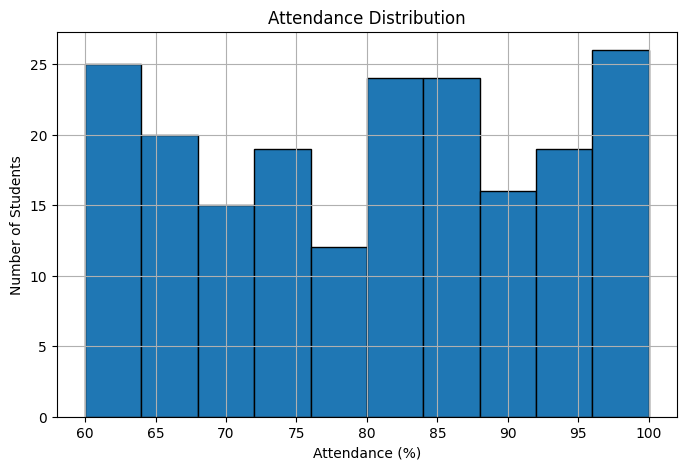

In [15]:
plt.figure(figsize=(8,5))

plt.hist(data["Attendance"],
         bins=10,
         edgecolor="black")

plt.title("Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")

plt.grid(True)

plt.show()

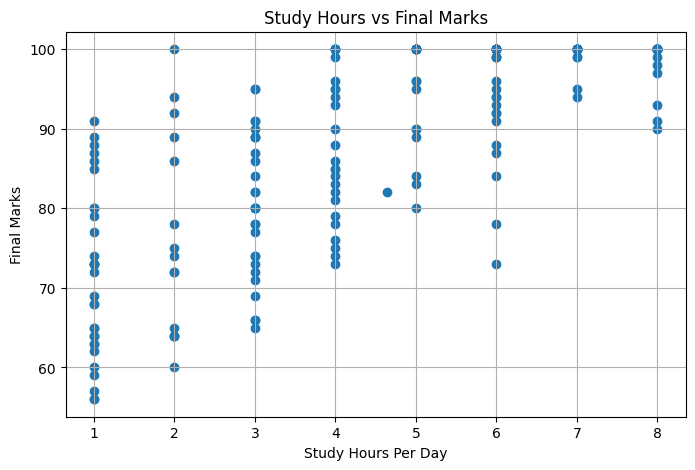

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(data["Study_Hours"],
            data["Final_Marks"])

plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Final Marks")

plt.grid(True)

plt.show()